<div style="text-align: center;">
    <h1>Support Vector Machine — Clasificación de Enfermedad Cardiovascular</h1>
</div>

## 1. Importar librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
import os
from scipy.stats import chi2_contingency, kendalltau, loguniform
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.dummy import DummyClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,fbeta_score,roc_auc_score,confusion_matrix,make_scorer,precision_recall_curve,RocCurveDisplay,classification_report

## 2. Cargar datos

Se carga directamente la base de datos ya limpia y preprocesada desde el repositorio GitHub del proyecto.

In [2]:
try:
    data = pd.read_csv("https://raw.githubusercontent.com/SantCorrea802/Cardiovascular_Disease_Proyecto_Modelos_II/main/dataset/data_cleaned.csv")
except FileNotFoundError:
    print("No se ha encontrado el archivo de datos. Verifique el directorio.")
    exit(1)

In [3]:
data.head()

,age,gender,height,weight,systolic_blood_pressure,diastolic_blood_pressure,cholesterol,glucose,smoke,alcohol_intake,physical_activity,bmi,cardiovascular_disease
0,50,2,168,62.0,110,80,1,1,0,0,1,1,0
1,55,1,156,85.0,140,90,3,1,0,0,1,3,1
2,52,1,165,64.0,130,70,3,1,0,0,0,1,1
3,48,2,169,82.0,150,100,1,1,0,0,1,2,1
4,48,1,156,56.0,100,60,1,1,0,0,0,1,0


## 3. Separación Train / Validation / Test

Se usa la misma estrategia del EDA: **80% train — 10% val — 10% test**, con estratificación para mantener la proporción de clases.

In [4]:
features = data.drop(columns=["cardiovascular_disease"])
target = data["cardiovascular_disease"]

#separar train del resto
X_train, X_temp, y_train, y_temp = train_test_split(features, target, test_size=0.20, random_state=42, stratify=target)
#separar test del val
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(X_train.shape, X_val.shape, X_test.shape)
print(y_train.shape, y_val.shape, y_test.shape)

# juntar data_train, data_test y data_val para el EDA
data_train = pd.concat([X_train, y_train], axis=1)
data_val = pd.concat([X_val, y_val], axis=1)
data_test = pd.concat([X_test, y_test], axis=1)

(54871, 12) (6859, 12) (6859, 12)
(54871,) (6859,) (6859,)


Separaremos caracteristicas según su categoria o clasificiación

In [5]:
categorical = ["gender", "cholesterol", "glucose", "smoke", "alcohol_intake", "physical_activity","bmi"]
nominal = ["gender", "smoke", "alcohol_intake", "physical_activity"]
ordinal = ["cholesterol", "glucose", "bmi"]
binary = ["gender","smoke", "alcohol_intake", "physical_activity"]
numerical = ["age", "height", "weight", "systolic_blood_pressure", "diastolic_blood_pressure"]

In [6]:
data["bmi"].unique()

array([1, 3, 2, 4, 0, 5])

## 4. Preprocesamiento obligatorio para SVM

Las maquinas de soporte vectorial dependen de distancias, márgenes y productos internos. Por eso el escalado es obligatorio

In [7]:
standar = numerical
onehot = nominal
# ordinal es la misma ordinal

# categorias para la ordinal
categorias = [
    [1,2,3],
    [1,2,3],
    [0,1,2,3,4,5]
]

ordinal_pipeline = Pipeline(
    steps=[
        ("encoder", OrdinalEncoder(
            categories=categorias,
            handle_unknown="use_encoded_value",
            unknown_value=-1,
            encoded_missing_value=-2
        )),
        ("scaler", StandardScaler())
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), standar),
        ("nom", OneHotEncoder(handle_unknown="ignore", sparse_output=True), onehot),
        ("ord", ordinal_pipeline, ordinal)
    ],
    remainder="drop"
)

## 5. Modelos Base
Antes de buscar hiperparámetros, entrenar modelos base

Usar **DummyClassifier** para responder a la pregunta ¿Mi modelo real es mejor que una estrategia tonta?

In [8]:
dummy_model = Pipeline(
    steps=[
        ("preprocess", preprocessor, ),
        ("model", DummyClassifier(strategy="most_frequent"))
    ]
)

dummy_model_trained = dummy_model.fit(X_train, y_train)

Usar **SVM Lineal**

In [9]:
linear_svm_base = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", LinearSVC(
            C=1.0,
            class_weight=None,
            max_iter=20_000,
            random_state=42
        ))
    ]
)

linear_svm_trained = linear_svm_base.fit(X_train, y_train)

Usar **SVM RBF**

In [10]:
rbf_svm_base = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            class_weight=None,
            cache_size=1000,
            random_state=42
        ))
    ]
)

svm_rbf_trained = rbf_svm_base.fit(X_train, y_train)

## 6. Función de evaluación

In [11]:
def get_scores(model, X, y, model_name):
    y_pred = model.predict(X)

    if hasattr(model, "decision_function"):
        y_score = model.decision_function(X)
    elif hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X)[:, 1]
    else:
        y_score = None

    cm = confusion_matrix(y, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    scores = {
        "model": model_name,
        "accuracy": accuracy_score(y, y_pred),
        "precision": precision_score(y, y_pred, zero_division=0),
        "recall": recall_score(y, y_pred, zero_division=0),
        "f1": f1_score(y, y_pred, zero_division=0),
        "f2": fbeta_score(y, y_pred, beta=2, zero_division=0),
        "roc_auc": roc_auc_score(y, y_score) if y_score is not None else None,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

    return scores, cm

In [12]:
def confusion_matrix_table(model, X, y):
    y_pred = model.predict(X)

    cm = confusion_matrix(y, y_pred, labels=[0, 1])
    cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100

    cm_combined = pd.DataFrame(
        [
            [
                f"{cm[i, j]} ({cm_percent[i, j]:.2f}%)"
                for j in range(cm.shape[1])
            ]
            for i in range(cm.shape[0])
        ],
        index=["Real 0: Sin enfermedad", "Real 1: Con enfermedad"],
        columns=["Predicho 0: Sin enfermedad", "Predicho 1: Con enfermedad"]
    )

    return cm_combined

In [13]:
models = {
    "Dummy": dummy_model_trained,
    "Linear SVM base": linear_svm_trained,
    "RBF SVM base": svm_rbf_trained
}

results = []
confusion_matrices = {}

for model_name, model in models.items():
    train_scores, train_cm = get_scores(
        model,
        X_train,
        y_train,
        model_name + " - train"
    )

    val_scores, val_cm = get_scores(
        model,
        X_val,
        y_val,
        model_name + " - validation"
    )

    results.append(train_scores)
    results.append(val_scores)

    confusion_matrices[model_name + " - train"] = train_cm
    confusion_matrices[model_name + " - validation"] = val_cm

base_results = pd.DataFrame(results)

# Métrica oficial para comparar modelos: ROC-AUC.
# F2, FN y recall quedan como criterios secundarios de análisis operativo.
base_results = base_results.sort_values(
    by=["roc_auc", "f2", "FN", "recall"],
    ascending=[False, False, True, False]
).round(4)

base_results

,model,accuracy,precision,recall,f1,f2,roc_auc,TN,FP,FN,TP
4,RBF SVM base - train,0.7364,0.7665,0.6724,0.7164,0.6893,0.7982,22143,5565,8898,18265
5,RBF SVM base - validation,0.7398,0.7686,0.6787,0.7209,0.6950,0.7974,2769,694,1091,2305
3,Linear SVM base - validation,0.7310,0.7605,0.6667,0.7105,0.6835,0.7963,2750,713,1132,2264
2,Linear SVM base - train,0.7253,0.7553,0.6582,0.7034,0.6756,0.7893,21917,5791,9284,17879
1,Dummy - validation,0.5049,0.0000,0.0000,0.0000,0.0000,0.5000,3463,0,3396,0
0,Dummy - train,0.5050,0.0000,0.0000,0.0000,0.0000,0.5000,27708,0,27163,0


In [14]:
confusion_matrix_table(svm_rbf_trained, X_val, y_val)

,Predicho 0: Sin enfermedad,Predicho 1: Con enfermedad
Real 0: Sin enfermedad,2769 (79.96%),694 (20.04%)
Real 1: Con enfermedad,1091 (32.13%),2305 (67.87%)


In [15]:
confusion_matrix_table(linear_svm_trained, X_val, y_val)

,Predicho 0: Sin enfermedad,Predicho 1: Con enfermedad
Real 0: Sin enfermedad,2750 (79.41%),713 (20.59%)
Real 1: Con enfermedad,1132 (33.33%),2264 (66.67%)


In [16]:
confusion_matrix_table(dummy_model_trained, X_val, y_val)

,Predicho 0: Sin enfermedad,Predicho 1: Con enfermedad
Real 0: Sin enfermedad,3463 (100.00%),0 (0.00%)
Real 1: Con enfermedad,3396 (100.00%),0 (0.00%)


## 7. Busqueda de hiperparametros

In [17]:
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

### Busqueda para linear SVM

In [18]:
# F2 se mantiene porque es importante para el contexto cardiovascular,
# pero la métrica oficial de búsqueda/selección será ROC-AUC,
# igual que en el notebook de Random Forest.

precision_scorer = make_scorer(
    precision_score,
    zero_division=0
)

recall_scorer = make_scorer(
    recall_score,
    zero_division=0
)

f1_scorer = make_scorer(
    f1_score,
    zero_division=0
)

f2_scorer = make_scorer(
    fbeta_score,
    beta=2,
    zero_division=0
)

scoring = {
    "accuracy": "accuracy",
    "precision": precision_scorer,
    "recall": recall_scorer,
    "f1": f1_scorer,
    "roc_auc": "roc_auc",
    "f2": f2_scorer
}

official_refit_metric = "roc_auc"

In [19]:
linear_svm = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", LinearSVC(
            max_iter=30000,
            random_state=42
        ))
    ]
)

linear_param_grid = {
    "model__C": np.logspace(-3, 3, 7),
    "model__class_weight": [None, "balanced"]
}


linear_search = GridSearchCV(
    estimator=linear_svm,
    param_grid=linear_param_grid,
    scoring=scoring,
    refit=official_refit_metric,
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

linear_search.fit(X_train, y_train)

linear_search.best_params_, linear_search.best_score_

({'model__C': np.float64(0.01), 'model__class_weight': None},
 np.float64(0.7890948542828357))

## Tabla resultados de Linear SVM

In [20]:
linear_results = pd.DataFrame(linear_search.cv_results_)

linear_summary = linear_results[
    [
        "param_model__C",
        "param_model__class_weight",
        "mean_test_accuracy",
        "mean_test_precision",
        "mean_test_recall",
        "mean_test_f1",
        "mean_test_f2",
        "mean_test_roc_auc",
        "std_test_roc_auc",
        "rank_test_roc_auc"
    ]
].sort_values("rank_test_roc_auc")

linear_summary.head(10)

,param_model__C,param_model__class_weight,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_f1,mean_test_f2,mean_test_roc_auc,std_test_roc_auc,rank_test_roc_auc
2,0.01,None,0.724736,0.754766,0.657622,0.702847,0.674994,0.789095,0.003438,1
4,0.10,None,0.724754,0.754734,0.657733,0.702896,0.675082,0.789094,0.003440,2
6,1.00,None,0.724773,0.754766,0.657733,0.702910,0.675087,0.789094,0.003440,3
8,10.00,None,0.724773,0.754766,0.657733,0.702910,0.675087,0.789094,0.003440,4
10,100.00,None,0.724773,0.754766,0.657733,0.702910,0.675087,0.789094,0.003440,5
12,1000.00,None,0.724773,0.754766,0.657733,0.702910,0.675087,0.789094,0.003440,6
9,10.00,balanced,0.725411,0.752082,0.664286,0.705460,0.680164,0.789084,0.003439,7
11,100.00,balanced,0.725411,0.752082,0.664286,0.705460,0.680164,0.789084,0.003439,8
13,1000.00,balanced,0.725411,0.752082,0.664286,0.705460,0.680164,0.789084,0.003439,9
7,1.00,balanced,0.725411,0.752082,0.664286,0.705460,0.680164,0.789084,0.003439,10


### Busqueda para RBF SVM

In [21]:
rbf_svm = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", SVC(
            kernel="rbf",
            cache_size=500,
            random_state=42
        ))
    ]
)

rbf_param_distributions = {
    "model__C": loguniform(1e-2, 1e3),
    "model__gamma": loguniform(1e-4, 1e1),
    "model__class_weight": [None, "balanced"]
}

rbf_search = RandomizedSearchCV(
    estimator=rbf_svm,
    param_distributions=rbf_param_distributions,
    n_iter=16,
    scoring=scoring,
    refit=official_refit_metric,
    cv=cv,
    n_jobs=2,
    random_state=42,
    return_train_score=False,
    verbose=2
)

rbf_search.fit(X_train, y_train)

rbf_search.best_params_, rbf_search.best_score_

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END model__C=0.7459343285726545, model__class_weight=None, model__gamma=0.0008263688714158015; total time= 1.6min
[CV] END model__C=0.7459343285726545, model__class_weight=None, model__gamma=0.0008263688714158015; total time= 1.5min
[CV] END model__C=79.15074397656205, model__class_weight=None, model__gamma=0.0006026889128682511; total time= 1.5min


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END model__C=0.7459343285726545, model__class_weight=None, model__gamma=0.0008263688714158015; total time= 1.6min
[CV] END model__C=0.7459343285726545, model__class_weight=None, model__gamma=0.0008263688714158015; total time= 1.5min
[CV] END model__C=0.7459343285726545, model__class_weight=None, model__gamma=0.0008263688714158015; total time= 1.5min
[CV] END model__C=79.15074397656205, model__class_weight=None, model__gamma=0.0006026889128682511; total time= 1.5min
[CV] END model__C=79.15074397656205, model__class_weight=None, model__gamma=0.0006026889128682511; total time= 1.6min
[CV] END model__C=0.060252157362038566, model__class_weight=None, model__gamma=0.019780827689353773; total time= 1.5min
[CV] END model__C=0.060252157362038566, model__class_weight=None, model__gamma=0.019780827689353773; total time= 1.5min
[CV] END model__C=0.060252157362038566, model__class_weight=None, model__gamma=0.019780827689353773; total time= 1.5min
[CV] END model__C=0.4661686413912768, model__cl

({'model__C': np.float64(492.90536482416695),
  'model__class_weight': 'balanced',
  'model__gamma': np.float64(0.0008111941985431928)},
 np.float64(0.7918199416106799))

### Tabla de resultados RBF

In [22]:
rbf_results = pd.DataFrame(rbf_search.cv_results_)

rbf_summary = rbf_results[
    [
        "param_model__C",
        "param_model__gamma",
        "param_model__class_weight",
        "mean_test_accuracy",
        "mean_test_precision",
        "mean_test_recall",
        "mean_test_f1",
        "mean_test_f2",
        "mean_test_roc_auc",
        "std_test_roc_auc",
        "rank_test_roc_auc"
    ]
].sort_values("rank_test_roc_auc")

rbf_summary.head(10)

,param_model__C,param_model__gamma,param_model__class_weight,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_f1,mean_test_f2,mean_test_roc_auc,std_test_roc_auc,rank_test_roc_auc
5,492.905365,0.000811,balanced,0.729383,0.749582,0.680779,0.713524,0.693509,0.791820,0.003034,1
12,10.907476,0.017885,None,0.731078,0.759865,0.667783,0.710850,0.684367,0.791628,0.002805,2
15,0.142715,0.015877,balanced,0.729001,0.759232,0.662740,0.707709,0.680023,0.791598,0.003271,3
10,84.310139,0.008172,None,0.731279,0.760651,0.667047,0.710777,0.683876,0.791540,0.002638,4
1,79.150744,0.000603,None,0.728819,0.761049,0.659169,0.706454,0.677302,0.791112,0.003112,5
11,824.431219,0.000171,None,0.728800,0.762874,0.656113,0.705476,0.675005,0.791065,0.003122,6
2,0.060252,0.019781,None,0.728928,0.764161,0.654383,0.705022,0.673739,0.790934,0.003348,7
6,0.082608,0.114358,balanced,0.730422,0.755495,0.673342,0.712052,0.688309,0.789880,0.003255,8
14,110.150568,0.000120,None,0.726431,0.772107,0.634724,0.696705,0.658143,0.789380,0.003523,9
0,0.745934,0.000826,None,0.724955,0.770897,0.632331,0.694765,0.655906,0.788818,0.003535,10


### Busqueda refinada

In [23]:
best_C = rbf_search.best_params_["model__C"]
best_gamma = rbf_search.best_params_["model__gamma"]
best_class_weight = rbf_search.best_params_["model__class_weight"]

refined_rbf_param_distributions = {
    "model__C": loguniform(
        max(best_C / 10, 1e-4),
        best_C * 10
    ),
    "model__gamma": loguniform(
        max(best_gamma / 10, 1e-6),
        best_gamma * 10
    ),
    "model__class_weight": [best_class_weight, None, "balanced"]
}

In [24]:
rbf_refined_search = RandomizedSearchCV(
    estimator=rbf_svm,
    param_distributions=refined_rbf_param_distributions,
    n_iter=12,
    scoring=scoring,
    refit=official_refit_metric,
    cv=cv,
    n_jobs=-1,
    random_state=123,
    return_train_score=False,
    verbose=2
)

rbf_refined_search.fit(X_train, y_train)

rbf_refined_search.best_params_, rbf_refined_search.best_score_

[CV] END model__C=79.15074397656205, model__class_weight=None, model__gamma=0.0006026889128682511; total time= 1.5min
[CV] END model__C=79.15074397656205, model__class_weight=None, model__gamma=0.0006026889128682511; total time= 1.5min
[CV] END model__C=0.060252157362038566, model__class_weight=None, model__gamma=0.019780827689353773; total time= 1.5min
[CV] END model__C=0.060252157362038566, model__class_weight=None, model__gamma=0.019780827689353773; total time= 1.5min
[CV] END model__C=0.4661686413912768, model__class_weight=balanced, model__gamma=0.3470266988650412; total time= 2.1min
[CV] END model__C=0.4661686413912768, model__class_weight=balanced, model__gamma=0.3470266988650412; total time= 2.2min
[CV] END model__C=0.4661686413912768, model__class_weight=balanced, model__gamma=0.3470266988650412; total time= 2.3min
[CV] END model__C=0.012674255898937233, model__class_weight=balanced, model__gamma=0.40737451960583815; total time= 2.1min
[CV] END model__C=0.012674255898937233, m

({'model__C': np.float64(1218.153216456519),
  'model__class_weight': 'balanced',
  'model__gamma': np.float64(0.0005835347024955959)},
 np.float64(0.7917594279665074))

### Crear tabla de modelos base

In [25]:
base_models = {
    "Dummy base": dummy_model_trained,
    "Linear SVM base": linear_svm_trained,
    "RBF SVM base": svm_rbf_trained
}

base_results = []

for model_name, model in base_models.items():
    scores, cm = get_scores(
        model=model,
        X=X_val,
        y=y_val,
        model_name=model_name
    )

    base_results.append(scores)

base_validation_results = pd.DataFrame(base_results).sort_values(
    by=["roc_auc", "f2", "FN", "recall"],
    ascending=[False, False, True, False]
)

base_validation_results

[CV] END model__C=1218.153216456519, model__class_weight=balanced, model__gamma=0.0005835347024955959; total time= 3.9min
[CV] END model__C=1187.225606719157, model__class_weight=None, model__gamma=0.0022287572843307946; total time= 5.4min
[CV] END model__C=1187.225606719157, model__class_weight=None, model__gamma=0.0022287572843307946; total time= 5.5min
[CV] END model__C=711.4627048362486, model__class_weight=None, model__gamma=0.0005142330071882642; total time= 3.0min
[CV] END model__C=711.4627048362486, model__class_weight=None, model__gamma=0.0005142330071882642; total time= 3.0min
[CV] END model__C=885.9262372108072, model__class_weight=None, model__gamma=0.0006113210148292703; total time= 3.2min
[CV] END model__C=64.8812694080305, model__class_weight=balanced, model__gamma=0.001250056479012542; total time= 2.9min
[CV] END model__C=904.3729842172982, model__class_weight=balanced, model__gamma=0.00011928279454287063; total time= 3.0min
[CV] END model__C=904.3729842172982, model__c

,model,accuracy,precision,recall,f1,f2,roc_auc,TN,FP,FN,TP
2,RBF SVM base,0.739758,0.768590,0.678740,0.720876,0.694989,0.797395,2769,694,1091,2305
1,Linear SVM base,0.731010,0.760497,0.666667,0.710497,0.683534,0.796289,2750,713,1132,2264
0,Dummy base,0.504884,0.000000,0.000000,0.000000,0.000000,0.500000,3463,0,3396,0


### Comparar en validación

In [26]:
best_linear_svm = linear_search.best_estimator_
best_rbf_svm = rbf_search.best_estimator_
best_rbf_refined_svm = rbf_refined_search.best_estimator_

models_tuned = {
    "Linear SVM tuned": best_linear_svm,
    "RBF SVM tuned": best_rbf_svm,
    "RBF SVM refined": best_rbf_refined_svm
}

tuned_results = []

for model_name, model in models_tuned.items():
    scores, cm = get_scores(
        model,
        X_val,
        y_val,
        model_name
    )

    tuned_results.append(scores)

tuned_results = pd.DataFrame(tuned_results).sort_values(
    by=["roc_auc", "f2", "FN", "recall"],
    ascending=[False, False, True, False]
)

tuned_results

,model,accuracy,precision,recall,f1,f2,roc_auc,TN,FP,FN,TP
1,RBF SVM tuned,0.735967,0.755893,0.689340,0.721084,0.701697,0.800442,2707,756,1055,2341
2,RBF SVM refined,0.735822,0.755319,0.689929,0.721145,0.702086,0.800386,2704,759,1053,2343
0,Linear SVM tuned,0.730865,0.760417,0.666372,0.710295,0.683273,0.796279,2750,713,1133,2263


### Unir

La siguiente celda une:

Modelos base:
- Dummy base
- Linear SVM base
- RBF SVM base

Modelos optimizados:
- Linear SVM tuned
- RBF SVM tuned sample

In [27]:
all_validation_results = pd.concat(
    [
        base_validation_results,
        tuned_results
    ],
    ignore_index=True
).sort_values(
    by=["roc_auc", "f2", "FN", "recall"],
    ascending=[False, False, True, False]
)

all_validation_results

,model,accuracy,precision,recall,f1,f2,roc_auc,TN,FP,FN,TP
3,RBF SVM tuned,0.735967,0.755893,0.689340,0.721084,0.701697,0.800442,2707,756,1055,2341
4,RBF SVM refined,0.735822,0.755319,0.689929,0.721145,0.702086,0.800386,2704,759,1053,2343
0,RBF SVM base,0.739758,0.768590,0.678740,0.720876,0.694989,0.797395,2769,694,1091,2305
1,Linear SVM base,0.731010,0.760497,0.666667,0.710497,0.683534,0.796289,2750,713,1132,2264
5,Linear SVM tuned,0.730865,0.760417,0.666372,0.710295,0.683273,0.796279,2750,713,1133,2263
2,Dummy base,0.504884,0.000000,0.000000,0.000000,0.000000,0.500000,3463,0,3396,0


## 8. Curvas ROC en validación

Se grafican las curvas ROC de los modelos SVM evaluados en el conjunto de validación.  
La curva ROC permite analizar la capacidad del modelo para separar pacientes con y sin enfermedad cardiovascular considerando distintos umbrales de decisión

El eje vertical representa la tasa de verdaderos positivos, también llamada recall o sensibilidad:

$$TPR = \frac{TP}{TP + FN}$$

El eje horizontal representa la tasa de falsos positivos:

$$FPR = \frac{FP}{FP + TN}$$

Un mejor modelo tendrá una curva más cercana a la esquina superior izquierda y un mayor valor de AUC-ROC.

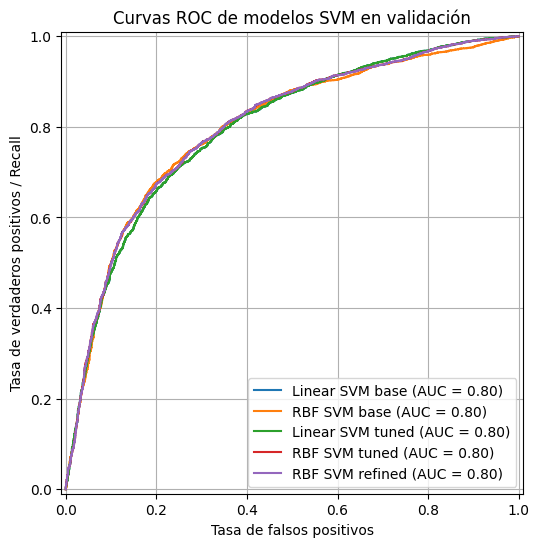

In [28]:
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_estimator(
    linear_svm_trained,
    X_val,
    y_val,
    ax=ax,
    name="Linear SVM base"
)

RocCurveDisplay.from_estimator(
    svm_rbf_trained,
    X_val,
    y_val,
    ax=ax,
    name="RBF SVM base"
)

RocCurveDisplay.from_estimator(
    best_linear_svm,
    X_val,
    y_val,
    ax=ax,
    name="Linear SVM tuned"
)

RocCurveDisplay.from_estimator(
    best_rbf_svm,
    X_val,
    y_val,
    ax=ax,
    name="RBF SVM tuned"
)

RocCurveDisplay.from_estimator(
    best_rbf_refined_svm,
    X_val,
    y_val,
    ax=ax,
    name="RBF SVM refined"
)

plt.title("Curvas ROC de modelos SVM en validación")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos / Recall")
plt.grid(True)
plt.show()

### Ajuste de umbral de decisión en validación

La búsqueda de hiperparámetros ya eligió el modelo por **ROC-AUC**.  
El ajuste de umbral no cambia el ROC-AUC del modelo; sirve para elegir un punto operativo concreto.

En este problema cardiovascular, tiene sentido ajustar el umbral con **F2-score**, porque F2 prioriza el recall y penaliza más los falsos negativos.

candidato

In [29]:
# Selección automática del candidato oficial según validación.
# Primero se usa ROC-AUC. F2/FN/recall quedan como criterios secundarios.
all_svm_models = {
    **base_models,
    **models_tuned
}

candidate_model_name = all_validation_results.iloc[0]["model"]
candidate_model = all_svm_models[candidate_model_name]

candidate_model_name

'RBF SVM tuned'

In [30]:
scores_val = candidate_model.decision_function(X_val)

# Umbrales candidatos. Incluye el threshold default de SVM: 0.0
thresholds = np.unique(
    np.r_[
        np.quantile(scores_val, np.linspace(0.01, 0.99, 99)),
        0.0
    ]
)

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (scores_val >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        y_pred_threshold,
        labels=[0, 1]
    ).ravel()

    threshold_results.append({
        "model": candidate_model_name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_val, y_pred_threshold),
        "precision": precision_score(y_val, y_pred_threshold, zero_division=0),
        "recall": recall_score(y_val, y_pred_threshold, zero_division=0),
        "f1": f1_score(y_val, y_pred_threshold, zero_division=0),
        "f2": fbeta_score(y_val, y_pred_threshold, beta=2, zero_division=0),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results_sorted = threshold_results.sort_values(
    by=["f2", "FN", "recall"],
    ascending=[False, True, False]
)

threshold_results_sorted.head(10)

,model,threshold,accuracy,precision,recall,f1,f2,TN,FP,FN,TP
5,RBF SVM tuned,-1.985743,0.544103,0.520862,0.988810,0.682312,0.838201,374,3089,38,3358
7,RBF SVM tuned,-1.831094,0.557370,0.528526,0.982038,0.687204,0.838192,488,2975,61,3335
6,RBF SVM tuned,-1.902981,0.550372,0.524459,0.984982,0.684469,0.837842,430,3033,51,3345
9,RBF SVM tuned,-1.650999,0.570054,0.536206,0.974676,0.691817,0.837678,600,2863,86,3310
8,RBF SVM tuned,-1.758951,0.563347,0.532126,0.977915,0.689219,0.837579,543,2920,75,3321
4,RBF SVM tuned,-2.029736,0.536084,0.516421,0.990872,0.678975,0.837065,312,3151,31,3365
10,RBF SVM tuned,-1.563422,0.576031,0.539974,0.970554,0.693895,0.837058,655,2808,100,3296
3,RBF SVM tuned,-2.068584,0.528211,0.512151,0.992933,0.675752,0.835978,251,3212,24,3372
11,RBF SVM tuned,-1.454066,0.580697,0.543075,0.965253,0.695081,0.835372,705,2758,118,3278
12,RBF SVM tuned,-1.343483,0.586674,0.547009,0.961131,0.697212,0.834740,760,2703,132,3264


In [31]:
# Guardar el mejor threshold encontrado en validación según F2.
# Este threshold se aplicará después en test, sin volverlo a ajustar.

In [47]:
best_threshold = threshold_results_sorted.iloc[0]["threshold"]
second_best_threshold = best_threshold = threshold_results_sorted.iloc[7]["threshold"]
best_threshold, second_best_threshold

(np.float64(-2.068584101264886), np.float64(-2.068584101264886))

### Comparar default (0.0) vs treshold ajustado

permite decir si con el threshold ajustado gané recall / reduje FN, pero aumenté o no aumenté FP

In [49]:
default_result = threshold_results.loc[
    threshold_results["threshold"].abs().idxmin()
]

adjusted_first_candidate = threshold_results_sorted.iloc[0]
adjusted_second_candidate = threshold_results_sorted.iloc[7]

pd.DataFrame([default_result, adjusted_first_candidate, adjusted_second_candidate], index=["Default threshold", "Adjusted first threshold", "Adjusted second threshold"])

,model,threshold,accuracy,precision,recall,f1,f2,TN,FP,FN,TP
Default threshold,RBF SVM tuned,0.000000,0.735967,0.755893,0.689340,0.721084,0.701697,2707,756,1055,2341
Adjusted first threshold,RBF SVM tuned,-1.985743,0.544103,0.520862,0.988810,0.682312,0.838201,374,3089,38,3358
Adjusted second threshold,RBF SVM tuned,-2.068584,0.528211,0.512151,0.992933,0.675752,0.835978,251,3212,24,3372


### Matriz de confusión con treshold ajustado

In [52]:
y_val_pred_adjusted_v1 = (scores_val >= best_threshold).astype(int)

cm_val_adjusted_v1 = confusion_matrix(
    y_val,
    y_val_pred_adjusted_v1,
    labels=[0, 1]
)

cm_val_adjusted_df_v1 = pd.DataFrame(
    cm_val_adjusted_v1,
    index=["Real 0: Sin enfermedad", "Real 1: Con enfermedad"],
    columns=["Predicho 0: Sin enfermedad", "Predicho 1: Con enfermedad"]
)

cm_val_adjusted_df_v1


,Predicho 0: Sin enfermedad,Predicho 1: Con enfermedad
Real 0: Sin enfermedad,251,3212
Real 1: Con enfermedad,24,3372


threshold segundo candidato

In [54]:
y_val_pred_adjusted_v2 = (scores_val >= second_best_threshold).astype(int)

cm_val_adjusted_v2 = confusion_matrix(
    y_val,
    y_val_pred_adjusted_v2,
    labels=[0, 1]
)

cm_val_adjusted_df_v2 = pd.DataFrame(
    cm_val_adjusted_v2,
    index=["Real 0: Sin enfermedad", "Real 1: Con enfermedad"],
    columns=["Predicho 0: Sin enfermedad", "Predicho 1: Con enfermedad"]
)

cm_val_adjusted_df_v2

,Predicho 0: Sin enfermedad,Predicho 1: Con enfermedad
Real 0: Sin enfermedad,251,3212
Real 1: Con enfermedad,24,3372


En porcentaje con primer candidato

In [56]:
cm_percent_v1 = cm_val_adjusted_v1 / cm_val_adjusted_v1.sum(axis=1, keepdims=True) * 100

cm_combined_v1 = pd.DataFrame(
    [
        [
            f"{cm_val_adjusted_v1[i, j]} ({cm_percent_v1[i, j]:.2f}%)"
            for j in range(cm_val_adjusted_v1.shape[1])
        ]
        for i in range(cm_val_adjusted_v1.shape[0])
    ],
    index=["Real 0: Sin enfermedad", "Real 1: Con enfermedad"],
    columns=["Predicho 0: Sin enfermedad", "Predicho 1: Con enfermedad"]
)

cm_combined_v1

,Predicho 0: Sin enfermedad,Predicho 1: Con enfermedad
Real 0: Sin enfermedad,251 (7.25%),3212 (92.75%)
Real 1: Con enfermedad,24 (0.71%),3372 (99.29%)


En porcentaje segundo candidato

In [58]:
cm_percent_v2 = cm_val_adjusted_v2 / cm_val_adjusted_v2.sum(axis=1, keepdims=True) * 100

cm_combined_v2 = pd.DataFrame(
    [
        [
            f"{cm_val_adjusted_v2[i, j]} ({cm_percent_v2[i, j]:.2f}%)"
            for j in range(cm_val_adjusted_v2.shape[1])
        ]
        for i in range(cm_val_adjusted_v2.shape[0])
    ],
    index=["Real 0: Sin enfermedad", "Real 1: Con enfermedad"],
    columns=["Predicho 0: Sin enfermedad", "Predicho 1: Con enfermedad"]
)

cm_combined_v2

,Predicho 0: Sin enfermedad,Predicho 1: Con enfermedad
Real 0: Sin enfermedad,251 (7.25%),3212 (92.75%)
Real 1: Con enfermedad,24 (0.71%),3372 (99.29%)


## Evaluación final en test

Hasta este punto, el conjunto de test no se había usado para tomar decisiones.  
Ahora se evalúa una única vez el modelo candidato seleccionado en validación.

Se reportan dos resultados:

1. **Threshold default de SVM**: `0.0` sobre `decision_function`.
2. **Threshold ajustado en validación**: `best_threshold`.

El segundo es el que corresponde si decidimos operar el modelo con el umbral ajustado.

In [36]:
def get_decision_scores(model, X):
    """Devuelve scores continuos para ROC-AUC y ajuste de threshold."""
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    raise ValueError("El modelo no expone decision_function ni predict_proba.")


def get_scores_from_predictions(y_true, y_pred, model_name, y_score=None):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score) if y_score is not None else np.nan,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }, cm

In [37]:
scores_test = get_decision_scores(candidate_model, X_test)

# Predicción default: para SVM equivale a threshold 0.0 en decision_function.
y_test_pred_default = candidate_model.predict(X_test)

# Predicción con threshold ajustado en validación.
y_test_pred_adjusted = (scores_test >= best_threshold).astype(int)

test_default_scores, test_default_cm = get_scores_from_predictions(
    y_true=y_test,
    y_pred=y_test_pred_default,
    model_name=f"{candidate_model_name} - test default threshold",
    y_score=scores_test
)

test_adjusted_scores, test_adjusted_cm = get_scores_from_predictions(
    y_true=y_test,
    y_pred=y_test_pred_adjusted,
    model_name=f"{candidate_model_name} - test adjusted threshold",
    y_score=scores_test
)

test_results = pd.DataFrame([
    test_default_scores,
    test_adjusted_scores
])

test_results

,model,accuracy,precision,recall,f1,f2,roc_auc,TN,FP,FN,TP
0,RBF SVM tuned - test default threshold,0.735967,0.760526,0.681001,0.718570,0.695548,0.795748,2736,728,1083,2312
1,RBF SVM tuned - test adjusted threshold,0.539146,0.518190,0.981738,0.678335,0.832750,0.795748,365,3099,62,3333


In [38]:
cm_test_adjusted_df = pd.DataFrame(
    test_adjusted_cm,
    index=["Real 0: Sin enfermedad", "Real 1: Con enfermedad"],
    columns=["Predicho 0: Sin enfermedad", "Predicho 1: Con enfermedad"]
)

cm_test_adjusted_df

,Predicho 0: Sin enfermedad,Predicho 1: Con enfermedad
Real 0: Sin enfermedad,365,3099
Real 1: Con enfermedad,62,3333


In [39]:
cm_percent_test = test_adjusted_cm / test_adjusted_cm.sum(axis=1, keepdims=True) * 100

cm_test_combined = pd.DataFrame(
    [
        [
            f"{test_adjusted_cm[i, j]} ({cm_percent_test[i, j]:.2f}%)"
            for j in range(test_adjusted_cm.shape[1])
        ]
        for i in range(test_adjusted_cm.shape[0])
    ],
    index=["Real 0: Sin enfermedad", "Real 1: Con enfermedad"],
    columns=["Predicho 0: Sin enfermedad", "Predicho 1: Con enfermedad"]
)

cm_test_combined

,Predicho 0: Sin enfermedad,Predicho 1: Con enfermedad
Real 0: Sin enfermedad,365 (10.54%),3099 (89.46%)
Real 1: Con enfermedad,62 (1.83%),3333 (98.17%)


In [40]:
print(classification_report(
    y_test,
    y_test_pred_adjusted,
    zero_division=0
))

              precision    recall  f1-score   support

           0       0.85      0.11      0.19      3464
           1       0.52      0.98      0.68      3395

    accuracy                           0.54      6859
   macro avg       0.69      0.54      0.43      6859
weighted avg       0.69      0.54      0.43      6859



## 9. Exportar modelo final

Se exporta un objeto tipo diccionario que contiene:

- el pipeline completo del modelo, incluyendo preprocesamiento;
- el threshold ajustado en validación;
- columnas esperadas;
- métrica oficial usada para selección;
- resumen de validación;
- resultados de test.

Esto evita repetir entrenamiento y permite cargar el modelo después para inferencia.

In [41]:
MODEL_FILENAME = "exported_svm.joblib"
MODEL_PATH = Path(MODEL_FILENAME)

model_bundle = {
    "model": candidate_model,
    "model_name": candidate_model_name,
    "threshold": float(best_threshold),
    "target_column": "cardiovascular_disease",
    "feature_columns": list(X_train.columns),
    "official_metric": official_refit_metric,
    "validation_results": all_validation_results,
    "test_results": test_results
}

joblib.dump(model_bundle, MODEL_PATH)

print(f"Modelo exportado correctamente en: {MODEL_PATH.resolve()}")

Modelo exportado correctamente en: /kaggle/working/exported_svm.joblib


In [42]:
# Ejemplo de carga del modelo exportado
# 


"""
UBICAR EL DIRECTORIO CORRECTO DE DONDE TENG EL MODELO
"""

loaded_bundle = joblib.load("exported_svm.joblib")
loaded_model = loaded_bundle["model"]
loaded_threshold = loaded_bundle["threshold"]

# Ejemplo de inferencia sobre X_test
loaded_scores = get_decision_scores(loaded_model, X_test)
loaded_predictions = (loaded_scores >= loaded_threshold).astype(int)

loaded_predictions[:10]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])